# Probar el modelo con Queries

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicción: Zoro
Confianza: 0.99486464


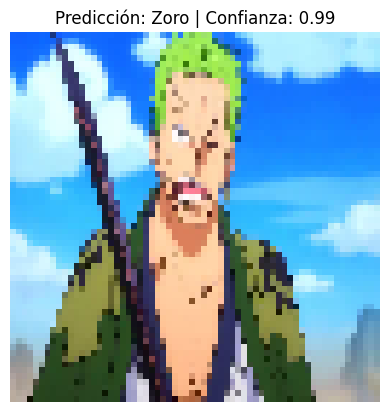

(np.str_('Zoro'), np.float32(0.99486464))

In [5]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

class_names = np.load("class_names.npy", allow_pickle=True) #Cargamos los nombres de las clases para la predicción

# Cargar el modelo guardado
model_query = tf.keras.models.load_model("best_model_tl_ft.keras")#Cargamos el modelo que guardamos con el mejor rendimiento para hacer las predicciones

# Función para preparar una imagen nueva
def cargar_imagen_query(image_path, img_size=(64, 64)): 
    img = tf.keras.utils.load_img(image_path, target_size=img_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img, img_array
#Cargamos la imagen que queremos que el modelo haga predicción y la preparamos para que pueda procesarla)

# Función para predecir una imagen 
def predecir_imagen(image_path):
    img, img_array = cargar_imagen_query(image_path)

    predictions = model_query.predict(img_array)#Hacemos la predicción con el modelo cargado utilizando la imagen que preparamos

    predicted_index = np.argmax(predictions[0])#Obtenemos el índice de la clase con la mayor probabilidad
    confidence = np.max(predictions[0])#Obtenemos la confianza de la predicción 

    predicted_class = class_names[predicted_index]#Sacamos el nombre de la clase de la predicción

    print("Predicción:", predicted_class)
    print("Confianza:", confidence)

    plt.imshow(img)
    plt.title(f"Predicción: {predicted_class} | Confianza: {confidence:.2f}")
    plt.axis("off")
    plt.show()

    return predicted_class, confidence

#La ruta de la imagen que queremos predecir
image_path = "/Users/arturosr/Desktop/OnePiece/OnePieceImage/Imagenes/OnePieceImagnesPrueba/02.png"

predecir_imagen(image_path)

In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

test_img = np.load("test_img.npy")
test_labels = np.load("test_labels.npy")

models_to_compare = {
    "CNN V2": "best_model.keras",
    "Transfer Learning": "best_model_tl.keras",
    "Transfer Learning + Fine-Tuning": "best_model_tl_ft.keras",
    "Saved CNN Model": "onepiece_model.keras"
}

results = []

for model_name, model_path in models_to_compare.items():
    model = tf.keras.models.load_model(model_path)

    y_pred_probs = model.predict(test_img)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)

    results.append({
        "Model": model_name,
        "Accuracy (%)": round(accuracy_score(test_labels, y_pred_classes) * 100, 2),
        "Precision (%)": round(precision_score(test_labels, y_pred_classes, average="weighted") * 100, 2),
        "Recall (%)": round(recall_score(test_labels, y_pred_classes, average="weighted") * 100, 2),
        "F1 Score (%)": round(f1_score(test_labels, y_pred_classes, average="weighted") * 100, 2)
    })

comparison_df = pd.DataFrame(results)
comparison_df

74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
74/74 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step
74/74 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,CNN V2,66.06,68.42,66.06,66.33
1,Transfer Learning,68.61,68.78,68.61,68.52
2,Transfer Learning + Fine-Tuning,71.64,71.95,71.64,71.58
3,Saved CNN Model,63.76,67.43,63.76,64.26
